# Tesla Deliveries & Production — End-to-End ML Pipeline
---

> **Dataset:** Tesla EA Deliveries and Production Data (2015–2025)  
> **Source:** Kaggle — `tesla_deliveries_dataset_2015_2025.csv`


## Library Imports

In [39]:
# Standard Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

#  for Visualization 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-Learn: Preprocessing 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Scikit-Learn: Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

#  Scikit-Learn: Metrics 
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, mean_absolute_percentage_error)

# Time-Series Forecasting 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Plotting Style 
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'figure.dpi': 120})

print(" All libraries imported successfully!")


 All libraries imported successfully!


## Data Loading & Initial Inspection

In [48]:
# Load the CSV dataset
CSV_PATH = 'tesla_deliveries_dataset_2015_2025.csv'   

df = pd.read_csv(CSV_PATH)

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("── First 5 rows ──")
df.head()


Dataset shape : 2,640 rows × 12 columns

── First 5 rows ──


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [49]:
# Column data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [50]:
#Basic descriptive statistics for numeric columns
df.describe().T.style.background_gradient(cmap='Blues')


,count,mean,std,min,25%,50%,75%,max
Year,2640.000000,2020.000000,3.162877,2015.000000,2017.000000,2020.000000,2023.000000,2025.000000
Month,2640.000000,6.500000,3.452707,1.000000,3.750000,6.500000,9.250000,12.000000
Estimated_Deliveries,2640.000000,9922.199621,3935.950093,48.000000,7292.000000,9857.000000,12510.250000,25704.000000
Production_Units,2640.000000,10655.847348,4260.600858,50.000000,7828.250000,10546.500000,13469.000000,28939.000000
Avg_Price_USD,2640.000000,84907.340330,20123.258036,50003.700000,67726.365000,85058.510000,102373.042500,119965.360000
Battery_Capacity_kWh,2640.000000,87.059470,20.836265,60.000000,75.000000,82.000000,100.000000,120.000000
Range_km,2640.000000,500.257576,120.868549,330.000000,418.000000,470.000000,586.250000,719.000000
CO2_Saved_tons,2640.000000,744.076989,353.221224,3.070000,499.620000,699.515000,943.765000,2548.550000
Charging_Stations,2640.000000,8932.133712,3469.565883,3002.000000,5897.750000,8901.500000,11938.000000,14996.000000


## Data Preprocessing & Cleaning

In [51]:
#Missing values audit
missing = df.isnull().sum()
pct_missing = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct_missing})
print("Missing value summary:")
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].any() else "No missing values found!")


Missing value summary:
No missing values found!


In [52]:
#Duplicate rows check
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")
if dups > 0:
    df = df.drop_duplicates()
    print(f"  → Dropped {dups} duplicates. New shape: {df.shape}")
else:
    print(" No duplicates found.")


Duplicate rows: 0
 No duplicates found.


Outlier counts (IQR method):
                      Outlier Count
Estimated_Deliveries             12
Production_Units                 12
Avg_Price_USD                     0
Battery_Capacity_kWh              0
Range_km                          0
CO2_Saved_tons                   45
Charging_Stations                 0


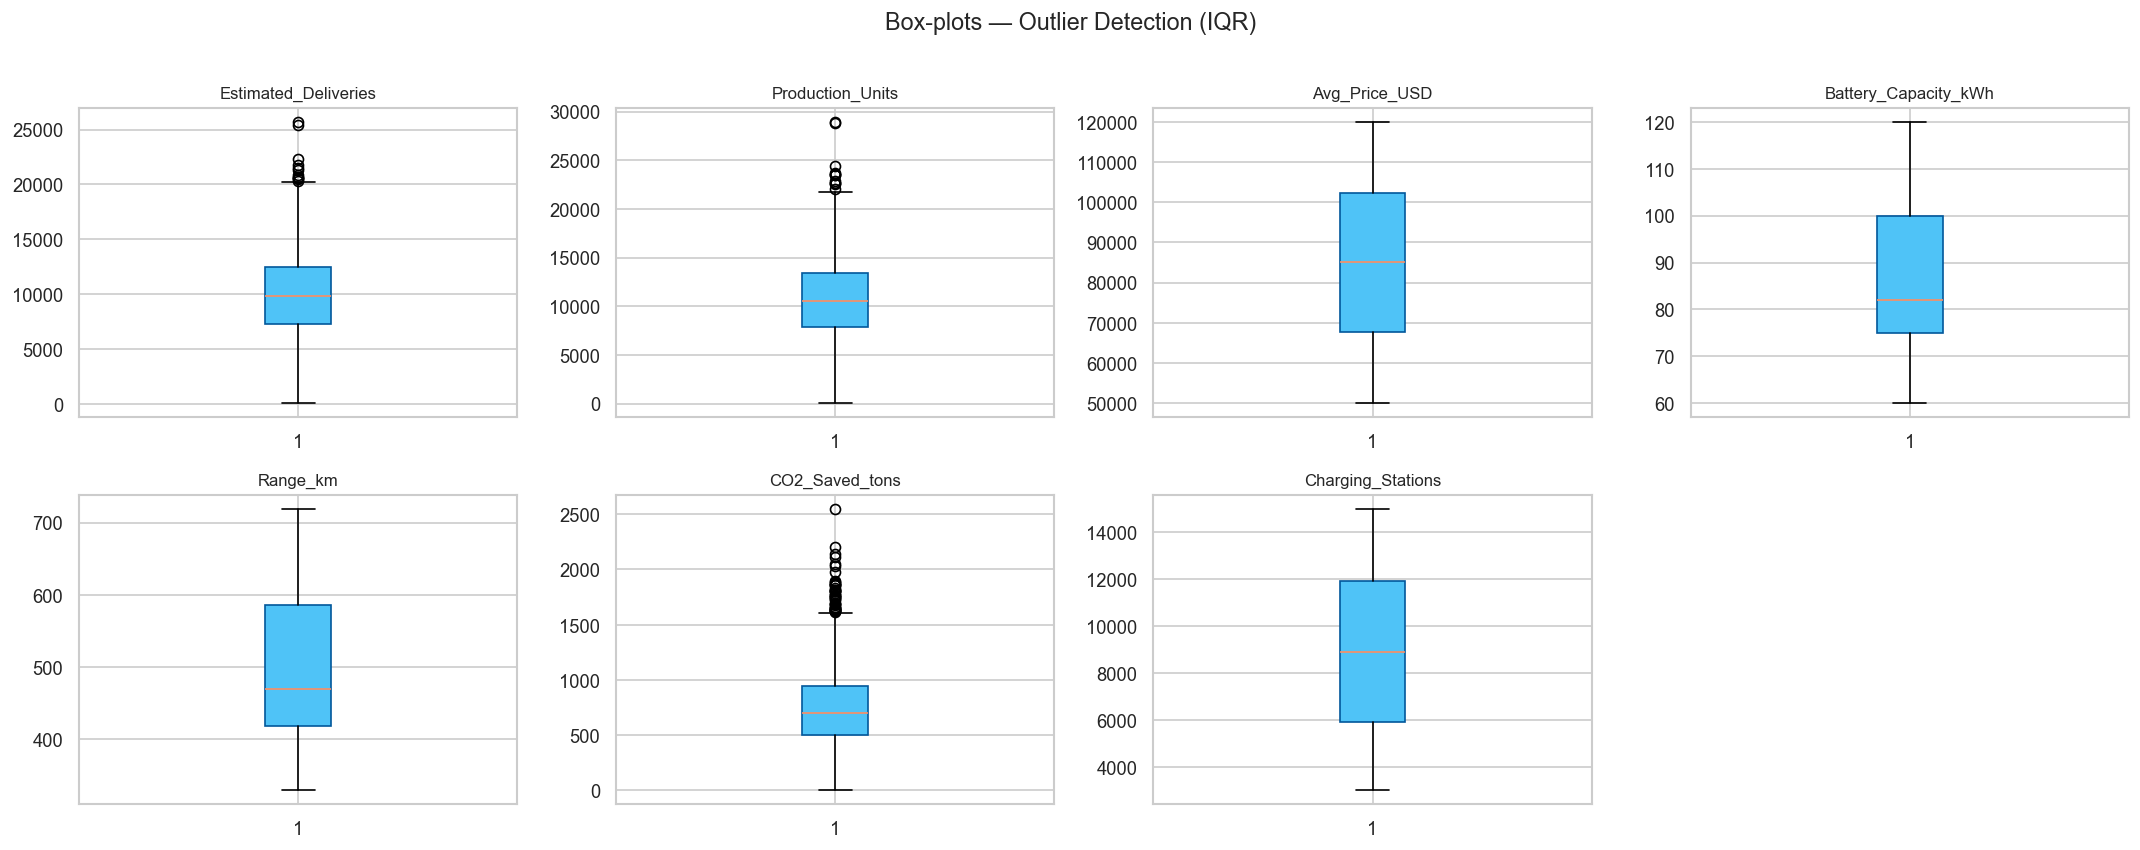

In [53]:
# Outlier detection using IQR for key numeric columns
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

outlier_summary = {}
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary[col] = n_out

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
print("Outlier counts (IQR method):")
print(outlier_df)

# Box-plots for visual outlier detection
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#4fc3f7', color='#01579b'))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
axes[-1].set_visible(False)
plt.suptitle('Box-plots — Outlier Detection (IQR)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [54]:
# Encode categorical columns
df_ml = df.copy()

le = LabelEncoder()
df_ml['Region_enc']  = le.fit_transform(df_ml['Region'])
df_ml['Model_enc']   = le.fit_transform(df_ml['Model'])
df_ml['Source_enc']  = le.fit_transform(df_ml['Source_Type'])

print("Encoded columns added:")
print(df_ml[['Region', 'Region_enc', 'Model', 'Model_enc']].drop_duplicates().sort_values('Region'))


Encoded columns added:
           Region  Region_enc       Model  Model_enc
13           Asia           0     Model S          2
1            Asia           0     Model X          3
22           Asia           0     Model Y          4
6            Asia           0     Model 3          1
11           Asia           0  Cybertruck          0
51         Europe           1     Model X          3
27         Europe           1     Model 3          1
91         Europe           1     Model Y          4
0          Europe           1     Model S          2
7          Europe           1  Cybertruck          0
20    Middle East           2     Model 3          1
4     Middle East           2     Model Y          4
25    Middle East           2  Cybertruck          0
31    Middle East           2     Model X          3
12    Middle East           2     Model S          2
14  North America           3  Cybertruck          0
23  North America           3     Model S          2
3   North America      

## Exploratory Data Analysis (EDA)

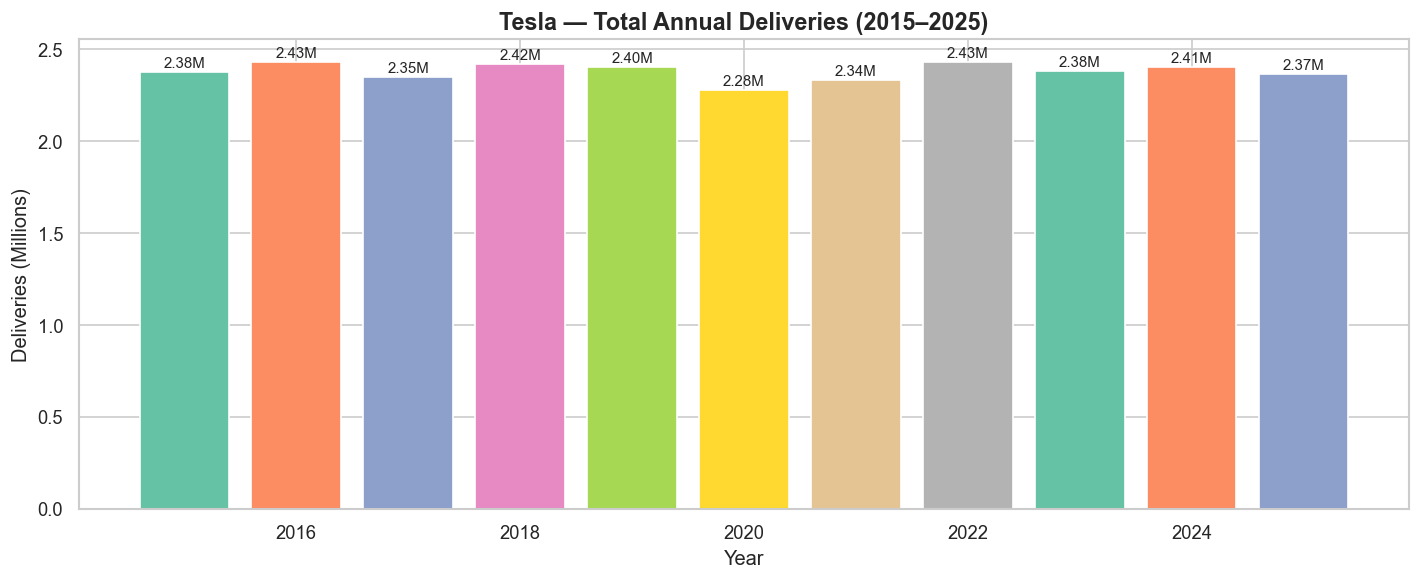

In [9]:
#Yearly total deliveries trend
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(yearly['Year'], yearly['Estimated_Deliveries'] / 1e6,
              color=sns.color_palette('Set2', len(yearly)))
ax.set_title('Tesla — Total Annual Deliveries (2015–2025)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Deliveries (Millions)')
for bar, val in zip(bars, yearly['Estimated_Deliveries']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val/1e6:.2f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()


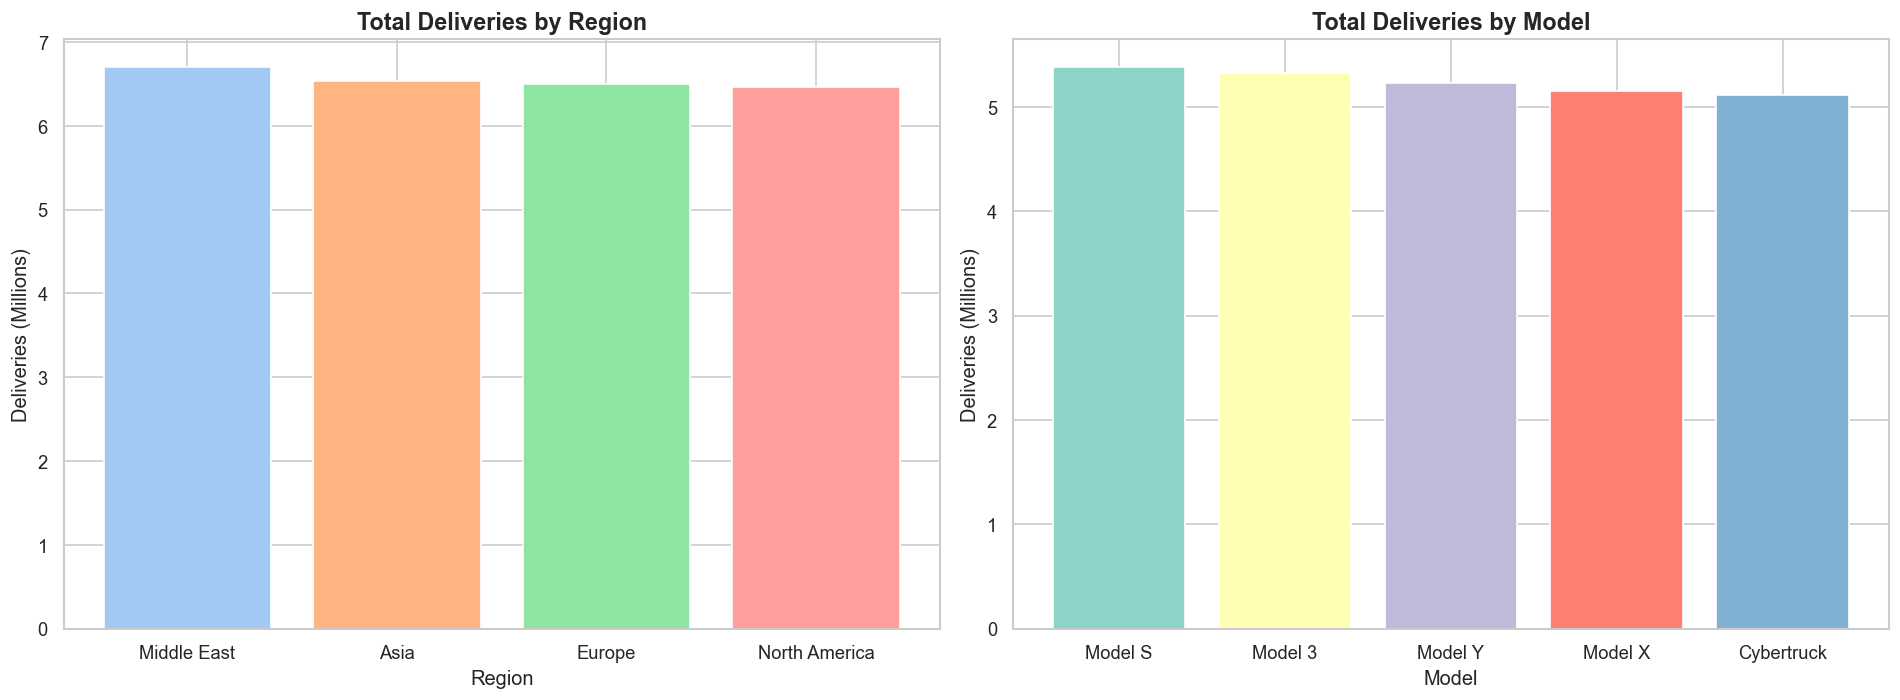

In [55]:
# Deliveries by Region and Model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By Region
region_total = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
axes[0].bar(region_total.index, region_total.values / 1e6,
            color=sns.color_palette('pastel', len(region_total)))
axes[0].set_title('Total Deliveries by Region', fontweight='bold')
axes[0].set_ylabel('Deliveries (Millions)'); axes[0].set_xlabel('Region')

# By Model
model_total = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
axes[1].bar(model_total.index, model_total.values / 1e6,
            color=sns.color_palette('Set3', len(model_total)))
axes[1].set_title('Total Deliveries by Model', fontweight='bold')
axes[1].set_ylabel('Deliveries (Millions)'); axes[1].set_xlabel('Model')

plt.tight_layout(); plt.show()


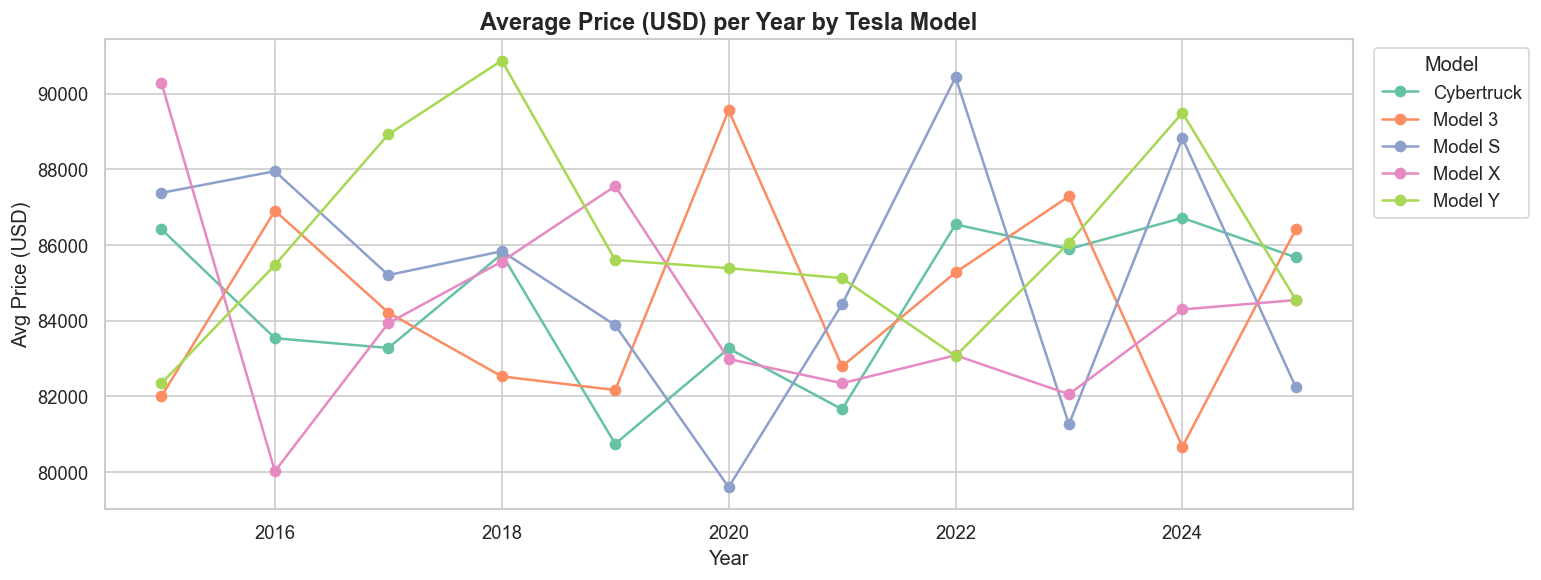

In [11]:
#Average Price trends by Model 
price_model_year = df.groupby(['Year', 'Model'])['Avg_Price_USD'].mean().unstack()

price_model_year.plot(marker='o', figsize=(13, 5))
plt.title('Average Price (USD) per Year by Tesla Model', fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Avg Price (USD)')
plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()


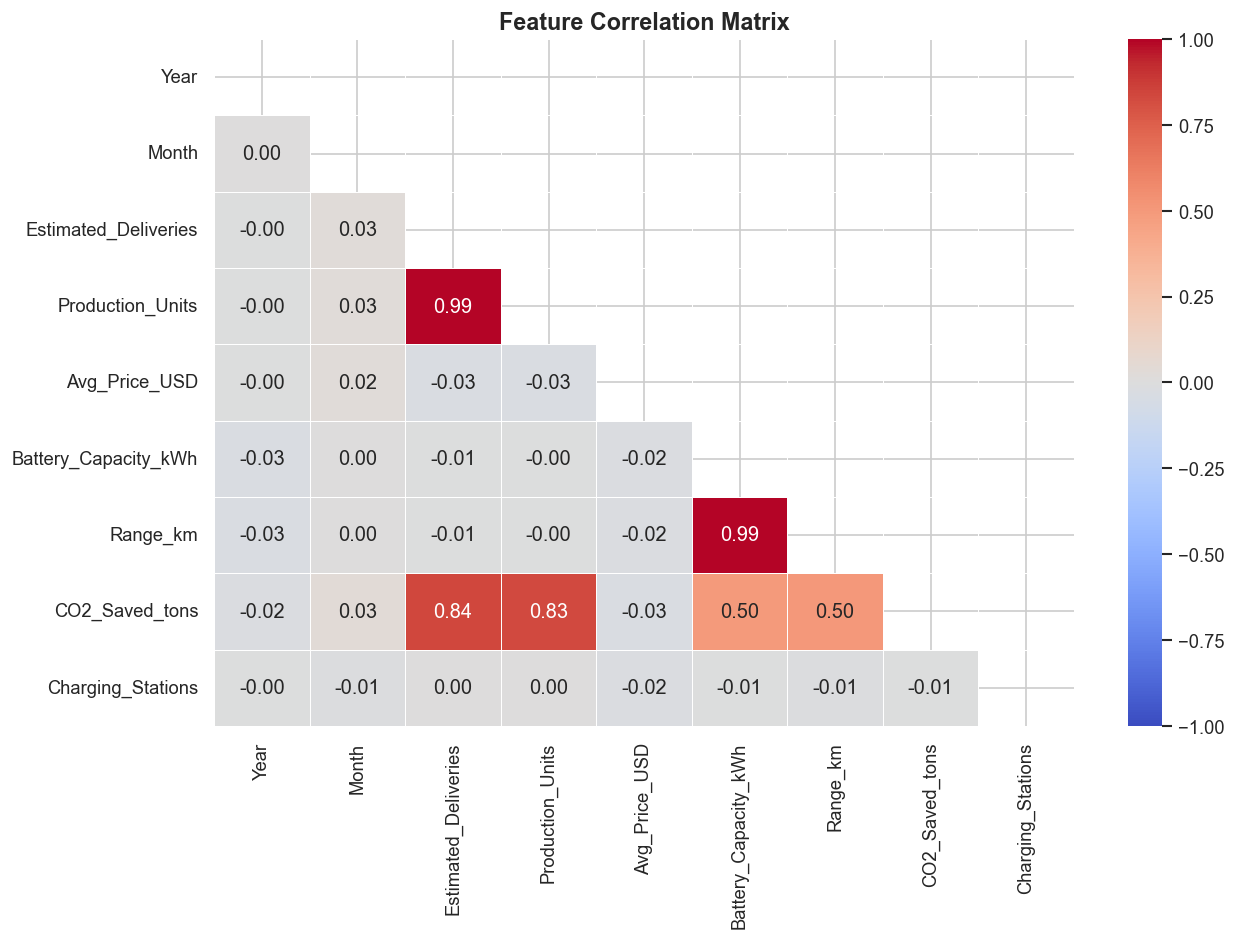

In [12]:
# Correlation heatmap 
corr_cols = ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
             'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
             'CO2_Saved_tons', 'Charging_Stations']

corr = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.show()


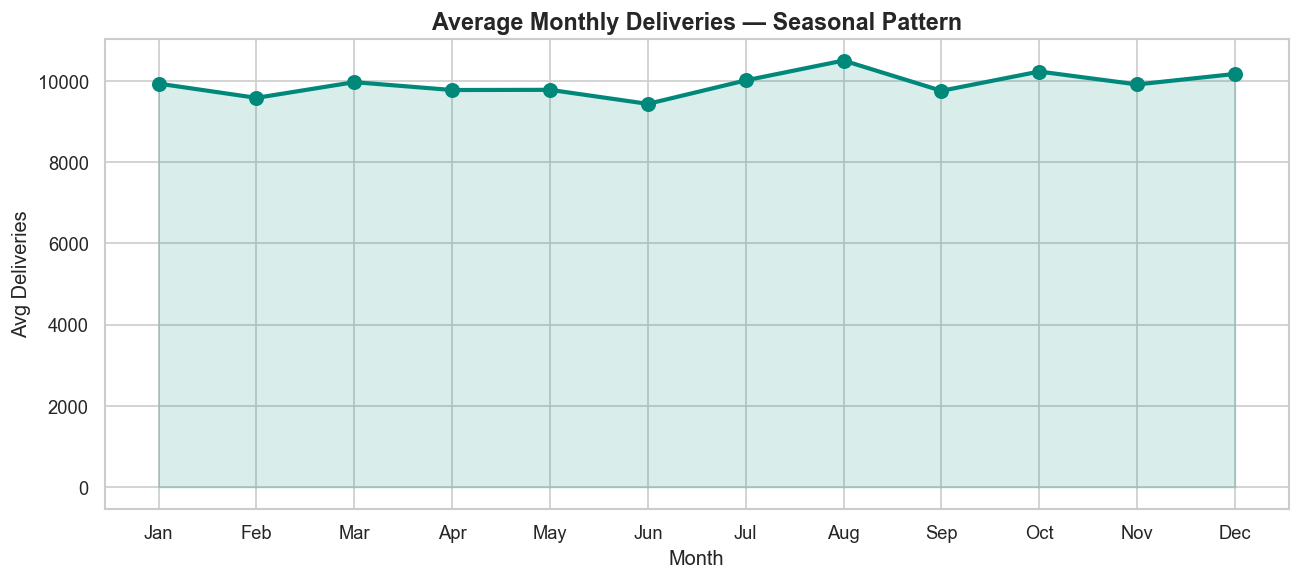

In [56]:
# Monthly seasonality pattern 
monthly = df.groupby('Month')['Estimated_Deliveries'].mean()

plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly.values, marker='o', linewidth=2.5,
         color='#00897b', markersize=8)
plt.fill_between(monthly.index, monthly.values, alpha=0.15, color='#00897b')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Average Monthly Deliveries — Seasonal Pattern', fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Avg Deliveries')
plt.tight_layout(); plt.show()


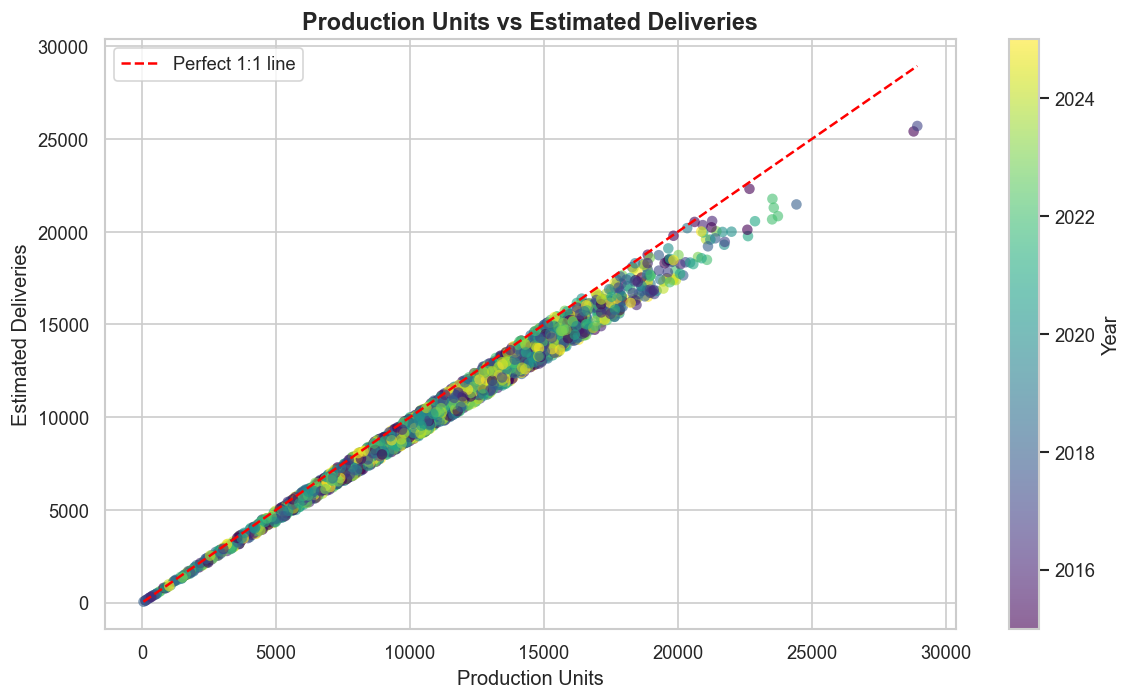

In [14]:
# Production vs Deliveries scatter
plt.figure(figsize=(10, 6))
sc = plt.scatter(df['Production_Units'], df['Estimated_Deliveries'],
                 c=df['Year'], cmap='viridis', alpha=0.6, edgecolors='none', s=40)
plt.colorbar(sc, label='Year')
plt.title('Production Units vs Estimated Deliveries', fontweight='bold')
plt.xlabel('Production Units'); plt.ylabel('Estimated Deliveries')

# Perfect correlation reference line
mn = min(df['Production_Units'].min(), df['Estimated_Deliveries'].min())
mx = max(df['Production_Units'].max(), df['Estimated_Deliveries'].max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect 1:1 line')
plt.legend(); plt.tight_layout(); plt.show()


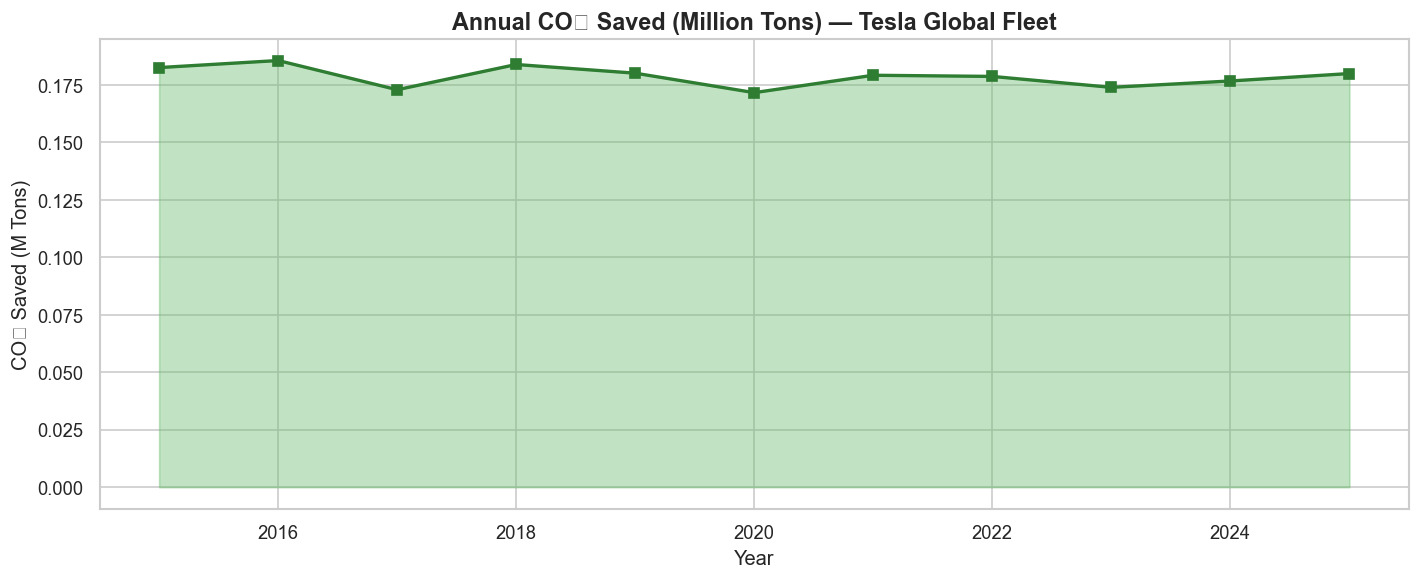

In [57]:
#  CO2 Savings growth ──
co2_year = df.groupby('Year')['CO2_Saved_tons'].sum() / 1e6

plt.figure(figsize=(12, 5))
plt.fill_between(co2_year.index, co2_year.values, alpha=0.4, color='#66bb6a')
plt.plot(co2_year.index, co2_year.values, marker='s', color='#2e7d32', linewidth=2)
plt.title('Annual CO₂ Saved (Million Tons) — Tesla Global Fleet', fontweight='bold')
plt.xlabel('Year'); plt.ylabel('CO₂ Saved (M Tons)')
plt.tight_layout(); plt.show()


## Feature Engineering

In [58]:
# Derive new features from existing columns ──

df_ml['Delivery_Efficiency'] = (
    df_ml['Estimated_Deliveries'] / df_ml['Production_Units']
).round(4)                          # % of produced cars that were delivered

df_ml['Revenue_est_USD']     = (
    df_ml['Estimated_Deliveries'] * df_ml['Avg_Price_USD']
).astype(np.int64)                  # Estimated revenue per record

df_ml['Price_per_km']        = (
    df_ml['Avg_Price_USD'] / df_ml['Range_km']
).round(2)                          # Cost efficiency ($ per km of range)

df_ml['Quarter']             = pd.cut(df_ml['Month'], bins=[0,3,6,9,12],
                                       labels=[1,2,3,4]).astype(int)   # Calendar quarter

df_ml['Year_sin']            = np.sin(2 * np.pi * (df_ml['Year'] - 2015) / 10)
df_ml['Month_sin']           = np.sin(2 * np.pi * df_ml['Month'] / 12)
df_ml['Month_cos']           = np.cos(2 * np.pi * df_ml['Month'] / 12)  # Cyclic month encoding

print("New features added:")
new_feats = ['Delivery_Efficiency','Revenue_est_USD','Price_per_km',
             'Quarter','Year_sin','Month_sin','Month_cos']
print(df_ml[new_feats].describe().T[['mean','min','max']].round(3))


New features added:
                             mean          min           max
Delivery_Efficiency  9.330000e-01        0.870  1.000000e+00
Revenue_est_USD      8.402867e+08  3427299.000  2.417428e+09
Price_per_km         1.800460e+02       69.900  3.593800e+02
Quarter              2.500000e+00        1.000  4.000000e+00
Year_sin            -0.000000e+00       -0.951  9.510000e-01
Month_sin           -0.000000e+00       -1.000  1.000000e+00
Month_cos           -0.000000e+00       -1.000  1.000000e+00


In [59]:
# Final feature set for modeling ──
FEATURE_COLS = [
    'Year', 'Month', 'Month_sin', 'Month_cos', 'Quarter', 'Year_sin',
    'Region_enc', 'Model_enc', 'Source_enc',
    'Production_Units', 'Battery_Capacity_kWh', 'Range_km',
    'Charging_Stations', 'Delivery_Efficiency', 'Price_per_km'
]

TARGET = 'Avg_Price_USD'     # ← Regression target: predict average selling price

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Target — mean: ${y.mean():,.0f}  |  std: ${y.std():,.0f}  |  range: ${y.min():,.0f}–${y.max():,.0f}")


Feature matrix shape : (2640, 15)
Target vector shape  : (2640,)
Target — mean: $84,907  |  std: $20,123  |  range: $50,004–$119,965


## Train / Test Split & Scaling

In [61]:
# 80/20 stratified split (stratify on Region for balanced sampling)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set  : {X_train.shape[0]:,} rows")
print(f"Test set      : {X_test.shape[0]:,} rows")

# Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train to avoid data leakage
X_test_sc  = scaler.transform(X_test)

print("\nFeatures scaled with StandardScaler (fit on train only).")


Training set  : 2,112 rows
Test set      : 528 rows

Features scaled with StandardScaler (fit on train only).


## Regression Modeling & Comparison

In [62]:
# Define all candidate models 
models = {
    'Linear Regression'       : LinearRegression(),
    'Ridge Regression'        : Ridge(alpha=1.0),
    'Lasso Regression'        : Lasso(alpha=0.1),
    'ElasticNet'              : ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Decision Tree'           : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest'           : RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting'       : GradientBoostingRegressor(n_estimators=150, random_state=42),
    'AdaBoost'                : AdaBoostRegressor(n_estimators=100, random_state=42),
    'K-Nearest Neighbors'     : KNeighborsRegressor(n_neighbors=7),
    'Support Vector Regressor': SVR(kernel='rbf', C=100, epsilon=0.1),
}

def evaluate(model, X_tr, y_tr, X_te, y_te, scaled=False):
    """Train model and return a dict of metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    mae    = mean_absolute_error(y_te, y_pred)
    r2     = r2_score(y_te, y_pred)
    mape   = mean_absolute_percentage_error(y_te, y_pred) * 100
    cv_r2  = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE(%)': mape, 'CV R²(5-fold)': cv_r2}

results = {}
for name, model in models.items():
    # Use scaled data for SVR and KNN; raw for tree-based models
    use_sc = name in ('K-Nearest Neighbors', 'Support Vector Regressor',
                      'Linear Regression', 'Ridge Regression',
                      'Lasso Regression', 'ElasticNet')
    Xtr = X_train_sc if use_sc else X_train.values
    Xte = X_test_sc  if use_sc else X_test.values
    results[name] = evaluate(model, Xtr, y_tr=y_train, X_te=Xte, y_te=y_test)
    print(f"  ✔ {name:30s}  R²={results[name]['R²']:.4f}  RMSE=${results[name]['RMSE']:,.0f}")

results_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print("\n── Model Leaderboard ──")
results_df.style.highlight_max(subset=['R²', 'CV R²(5-fold)'], color='#c8e6c9')                .highlight_min(subset=['RMSE','MAE','MAPE(%)'], color='#c8e6c9')                .format({'RMSE':'${:,.0f}', 'MAE':'${:,.0f}', 'R²':'{:.4f}',
                        'MAPE(%)':'{:.2f}%', 'CV R²(5-fold)':'{:.4f}'})


  ✔ Linear Regression               R²=0.8996  RMSE=$6,153
  ✔ Ridge Regression                R²=0.8996  RMSE=$6,154
  ✔ Lasso Regression                R²=0.8996  RMSE=$6,153
  ✔ ElasticNet                      R²=0.8865  RMSE=$6,542
  ✔ Decision Tree                   R²=0.9897  RMSE=$1,966
  ✔ Random Forest                   R²=0.9979  RMSE=$886
  ✔ Gradient Boosting               R²=0.9943  RMSE=$1,472
  ✔ AdaBoost                        R²=0.9070  RMSE=$5,922
  ✔ K-Nearest Neighbors             R²=0.4686  RMSE=$14,156
  ✔ Support Vector Regressor        R²=0.1563  RMSE=$17,837

── Model Leaderboard ──


,RMSE,MAE,R²,MAPE(%),CV R²(5-fold)
Random Forest,$886,$657,0.9979,0.81%,0.9971
Gradient Boosting,"$1,472","$1,112",0.9943,1.37%,0.9947
Decision Tree,"$1,966","$1,501",0.9897,1.82%,0.9858
AdaBoost,"$5,922","$5,179",0.9070,6.64%,0.9167
Lasso Regression,"$6,153","$5,005",0.8996,6.04%,0.8995
Linear Regression,"$6,153","$5,005",0.8996,6.04%,0.8995
Ridge Regression,"$6,154","$5,005",0.8996,6.04%,0.8995
ElasticNet,"$6,542","$5,351",0.8865,6.46%,0.8878
K-Nearest Neighbors,"$14,156","$11,762",0.4686,15.24%,0.4618
Support Vector Regressor,"$17,837","$15,356",0.1563,20.01%,0.1306


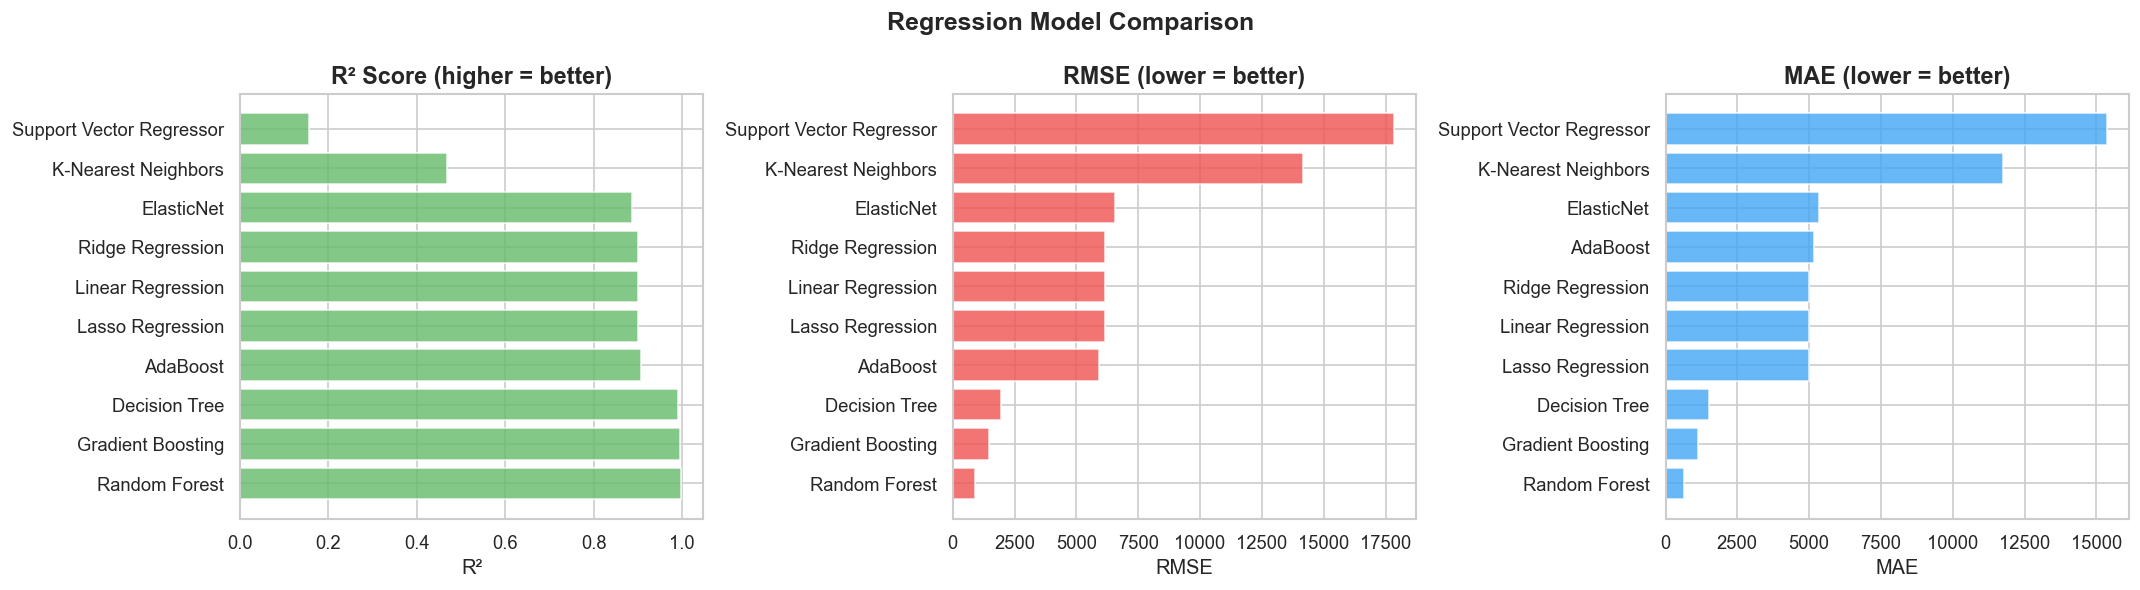

In [63]:
# Visual model comparison 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['R²', 'RMSE', 'MAE']
colors  = ['#66bb6a', '#ef5350', '#42a5f5']
titles  = ['R² Score (higher = better)', 'RMSE (lower = better)', 'MAE (lower = better)']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    rd = results_df.sort_values(metric, ascending=(metric != 'R²'))
    ax.barh(rd.index, rd[metric], color=color, alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(metric)

plt.suptitle('Regression Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


## Hyperparameter Tuning (Best Model)

In [65]:
# Identify the best model from the leaderboard
best_name = results_df['R²'].idxmax()
print(f"Best model from leaderboard: {best_name}")

param_dist_rf = {
    'n_estimators'      : [100, 200, 300, 400],
    'max_depth'         : [None, 10, 15, 20, 25],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2', 0.5],
    'bootstrap'         : [True, False]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_random = RandomizedSearchCV(
    estimator   = rf_base,
    param_distributions = param_dist_rf,
    n_iter      = 40,           # 40 random combinations
    scoring     = 'r2',
    cv          = 5,
    verbose     = 1,
    random_state= 42,
    n_jobs      = -1
)

rf_random.fit(X_train.values, y_train)

print(f"\n Best params: {rf_random.best_params_}")
print(f"   Best CV R²  : {rf_random.best_score_:.4f}")


Best model from leaderboard: Random Forest
Fitting 5 folds for each of 40 candidates, totalling 200 fits

 Best params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 25, 'bootstrap': False}
   Best CV R²  : 0.9895


── Tuned Random Forest — Test Set Metrics ──
  R²      : 0.9923
  RMSE    : $1,701.86
  MAE     : $1,287.90
  MAPE    : 1.64%


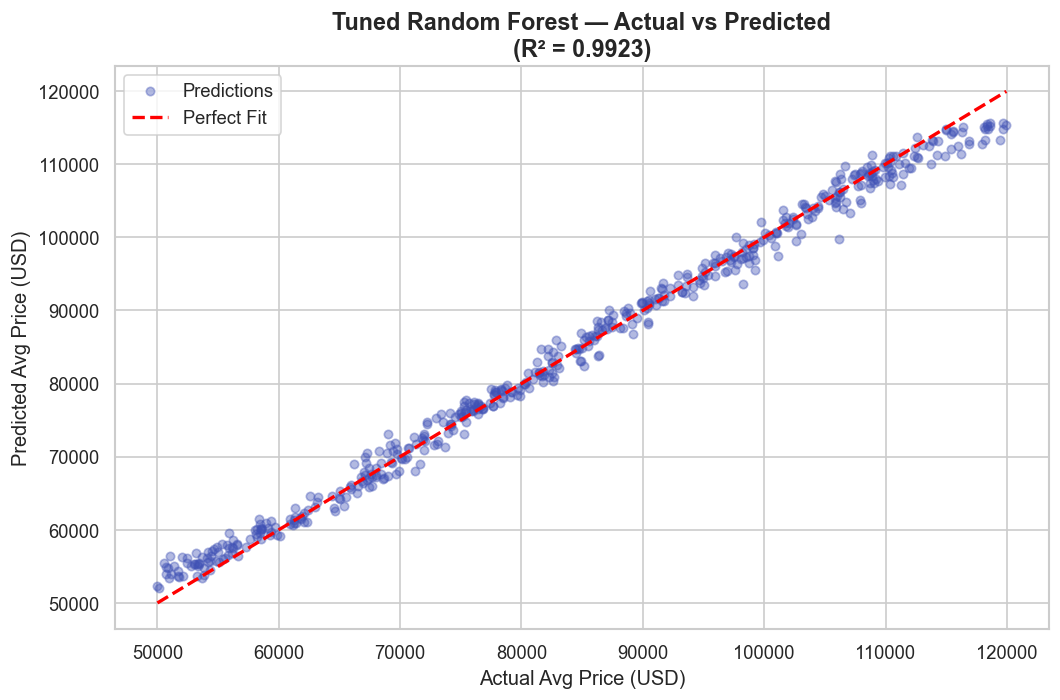

In [27]:
# Evaluate the tuned Random Forest on the test set 
rf_tuned = rf_random.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test.values)

rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_t  = mean_absolute_error(y_test, y_pred_tuned)
r2_t   = r2_score(y_test, y_pred_tuned)
mape_t = mean_absolute_percentage_error(y_test, y_pred_tuned) * 100

print("── Tuned Random Forest — Test Set Metrics ──")
print(f"  R²      : {r2_t:.4f}")
print(f"  RMSE    : ${rmse_t:,.2f}")
print(f"  MAE     : ${mae_t:,.2f}")
print(f"  MAPE    : {mape_t:.2f}%")

# Actual vs Predicted plot
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.4, color='#3f51b5', s=25, label='Predictions')
mn_val, mx_val = y_test.min(), y_test.max()
plt.plot([mn_val, mx_val], [mn_val, mx_val], 'r--', linewidth=2, label='Perfect Fit')
plt.title(f'Tuned Random Forest — Actual vs Predicted\n(R² = {r2_t:.4f})', fontweight='bold')
plt.xlabel('Actual Avg Price (USD)'); plt.ylabel('Predicted Avg Price (USD)')
plt.legend(); plt.tight_layout(); plt.show()


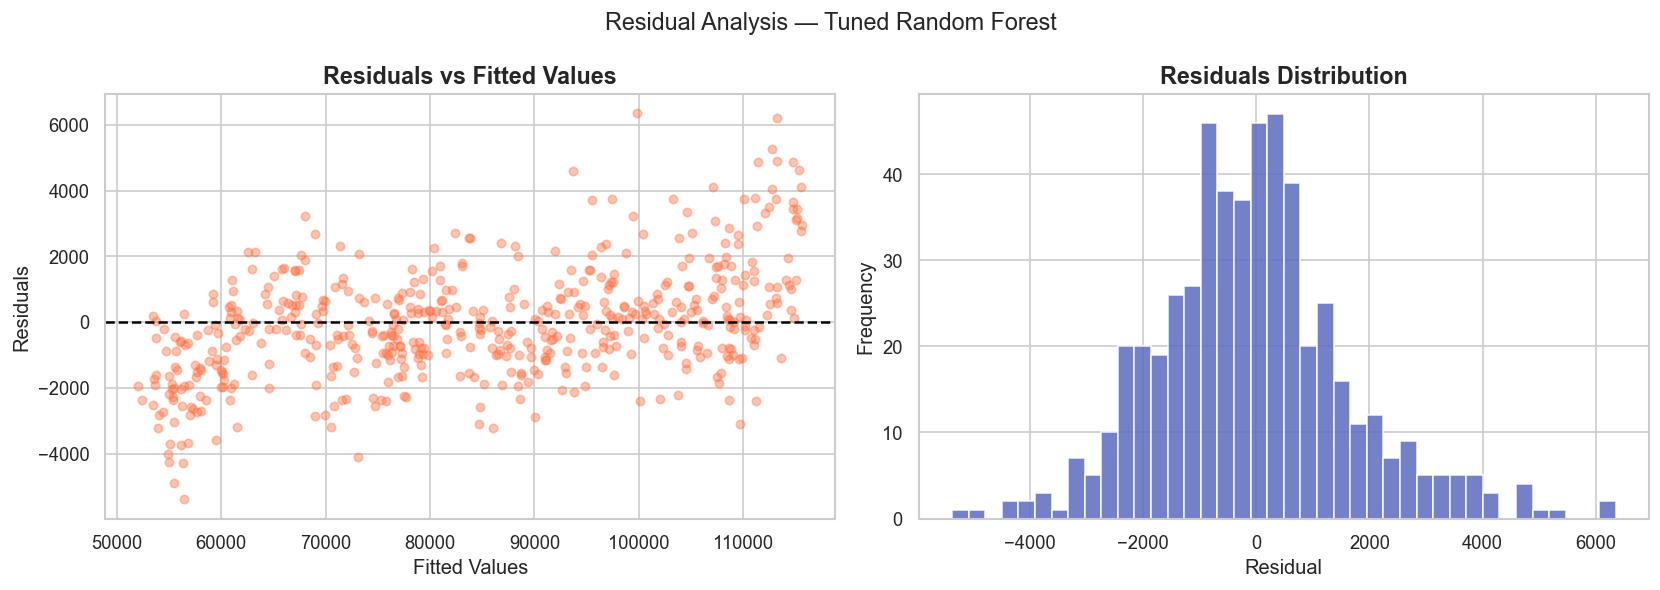

In [66]:
# Residual plot 
residuals = y_test.values - y_pred_tuned

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_tuned, residuals, alpha=0.4, color='#ff7043', s=25)
axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs Fitted Values', fontweight='bold')
axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')

axes[1].hist(residuals, bins=40, color='#5c6bc0', edgecolor='white', alpha=0.85)
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')

plt.suptitle('Residual Analysis — Tuned Random Forest', fontsize=14)
plt.tight_layout(); plt.show()


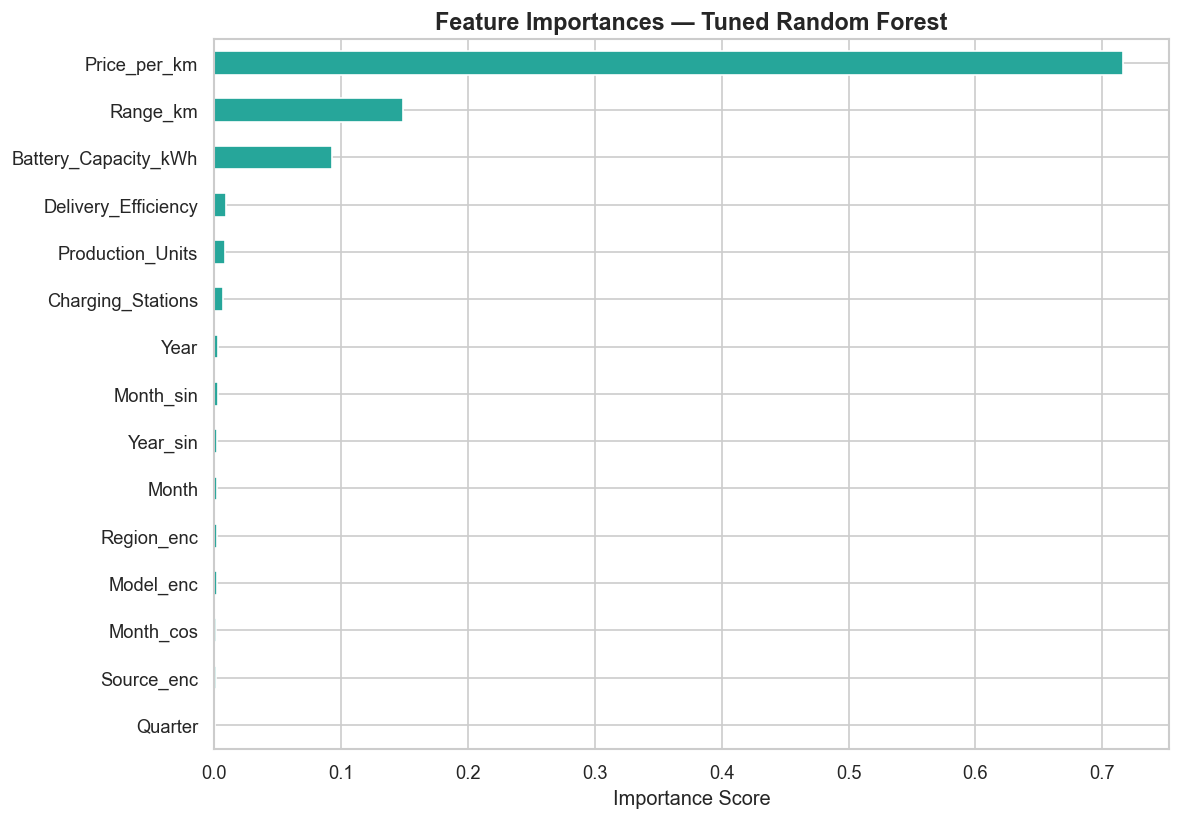

In [67]:
# Feature Importance from tuned Random Forest
importance = pd.Series(rf_tuned.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importance.plot(kind='barh', color='#26a69a', edgecolor='white')
plt.title('Feature Importances — Tuned Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()


## GridSearchCV on Gradient Boosting

In [68]:
# Grid search on Gradient Boosting
param_grid_gb = {
    'n_estimators'  : [100, 200],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 5, 7],
    'subsample'     : [0.8, 1.0]
}

gb_base = GradientBoostingRegressor(random_state=42)

gb_grid = GridSearchCV(
    estimator  = gb_base,
    param_grid = param_grid_gb,
    scoring    = 'r2',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

gb_grid.fit(X_train.values, y_train)

print(f"\nBest params : {gb_grid.best_params_}")
print(f"Best CV R²  : {gb_grid.best_score_:.4f}")

gb_best   = gb_grid.best_estimator_
gb_preds  = gb_best.predict(X_test.values)
print(f"Test R²     : {r2_score(y_test, gb_preds):.4f}")
print(f"Test RMSE   : ${np.sqrt(mean_squared_error(y_test, gb_preds)):,.2f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params : {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV R²  : 0.9986
Test R²     : 0.9990
Test RMSE   : $615.81


## Time-Series Forecasting

Time series: 2015-01-01 → 2025-12-01 | 132 months
Avg monthly deliveries: 198,444


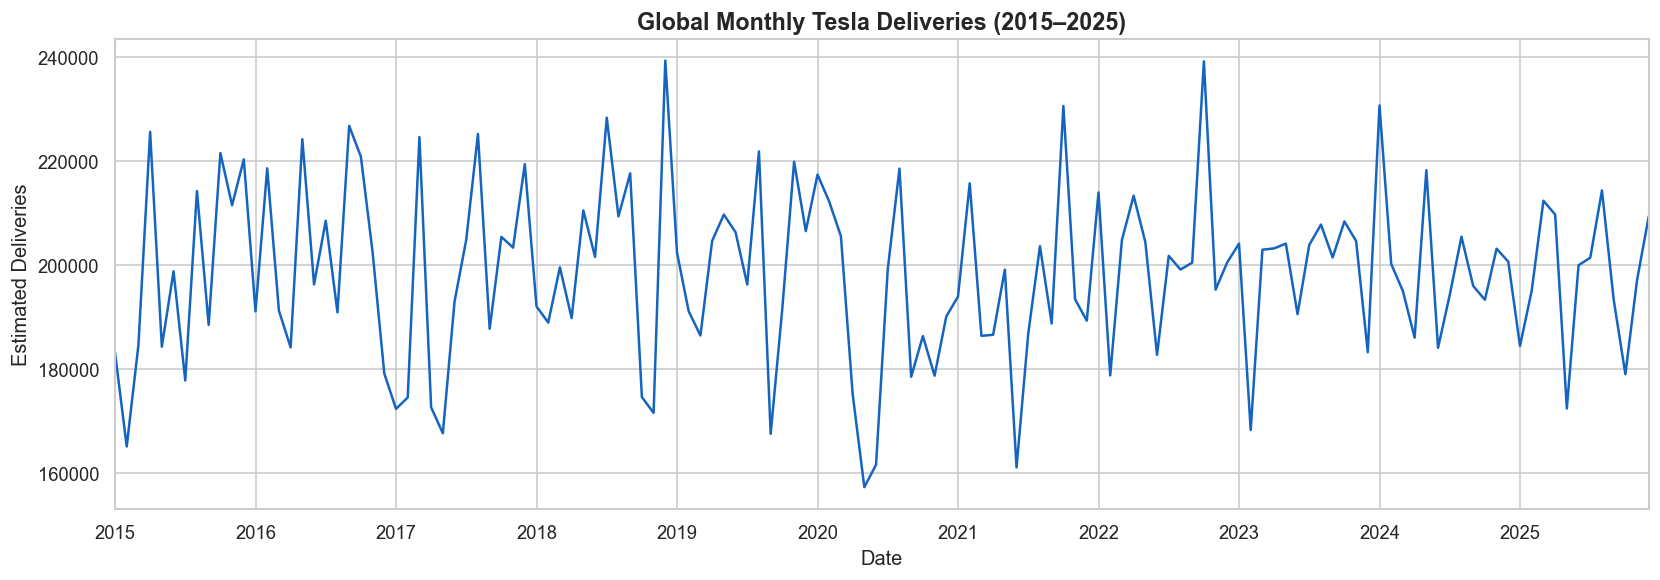

In [69]:
# Aggregate to monthly global deliveries
ts_df = (df.groupby(['Year', 'Month'])['Estimated_Deliveries']
           .sum()
           .reset_index())

ts_df['Date'] = pd.to_datetime(
    ts_df['Year'].astype(str) + '-' + ts_df['Month'].astype(str).str.zfill(2) + '-01'
)
ts_df = ts_df.sort_values('Date').set_index('Date')
ts = ts_df['Estimated_Deliveries']

print(f"Time series: {ts.index[0].date()} → {ts.index[-1].date()} | {len(ts)} months")
print(f"Avg monthly deliveries: {ts.mean():,.0f}")

plt.figure(figsize=(14, 5))
ts.plot(color='#1565c0', linewidth=1.5)
plt.title('Global Monthly Tesla Deliveries (2015–2025)', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Estimated Deliveries')
plt.tight_layout(); plt.show()


In [71]:
# Stationarity test (Augmented Dickey-Fuller) 
adf_result = adfuller(ts, autolag='AIC')

print("── Augmented Dickey-Fuller Test ──")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
print(f"  Critical Values:")
for key, val in adf_result[4].items():
    print(f"    {key}: {val:.4f}")

if adf_result[1] < 0.05:
    print("\n Series is STATIONARY (p < 0.05) — no differencing needed.")
else:
    print("\n Series is NON-STATIONARY — differencing may be required.")


── Augmented Dickey-Fuller Test ──
  ADF Statistic : -8.8810
  p-value       : 0.0000
  Critical Values:
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788

 Series is STATIONARY (p < 0.05) — no differencing needed.


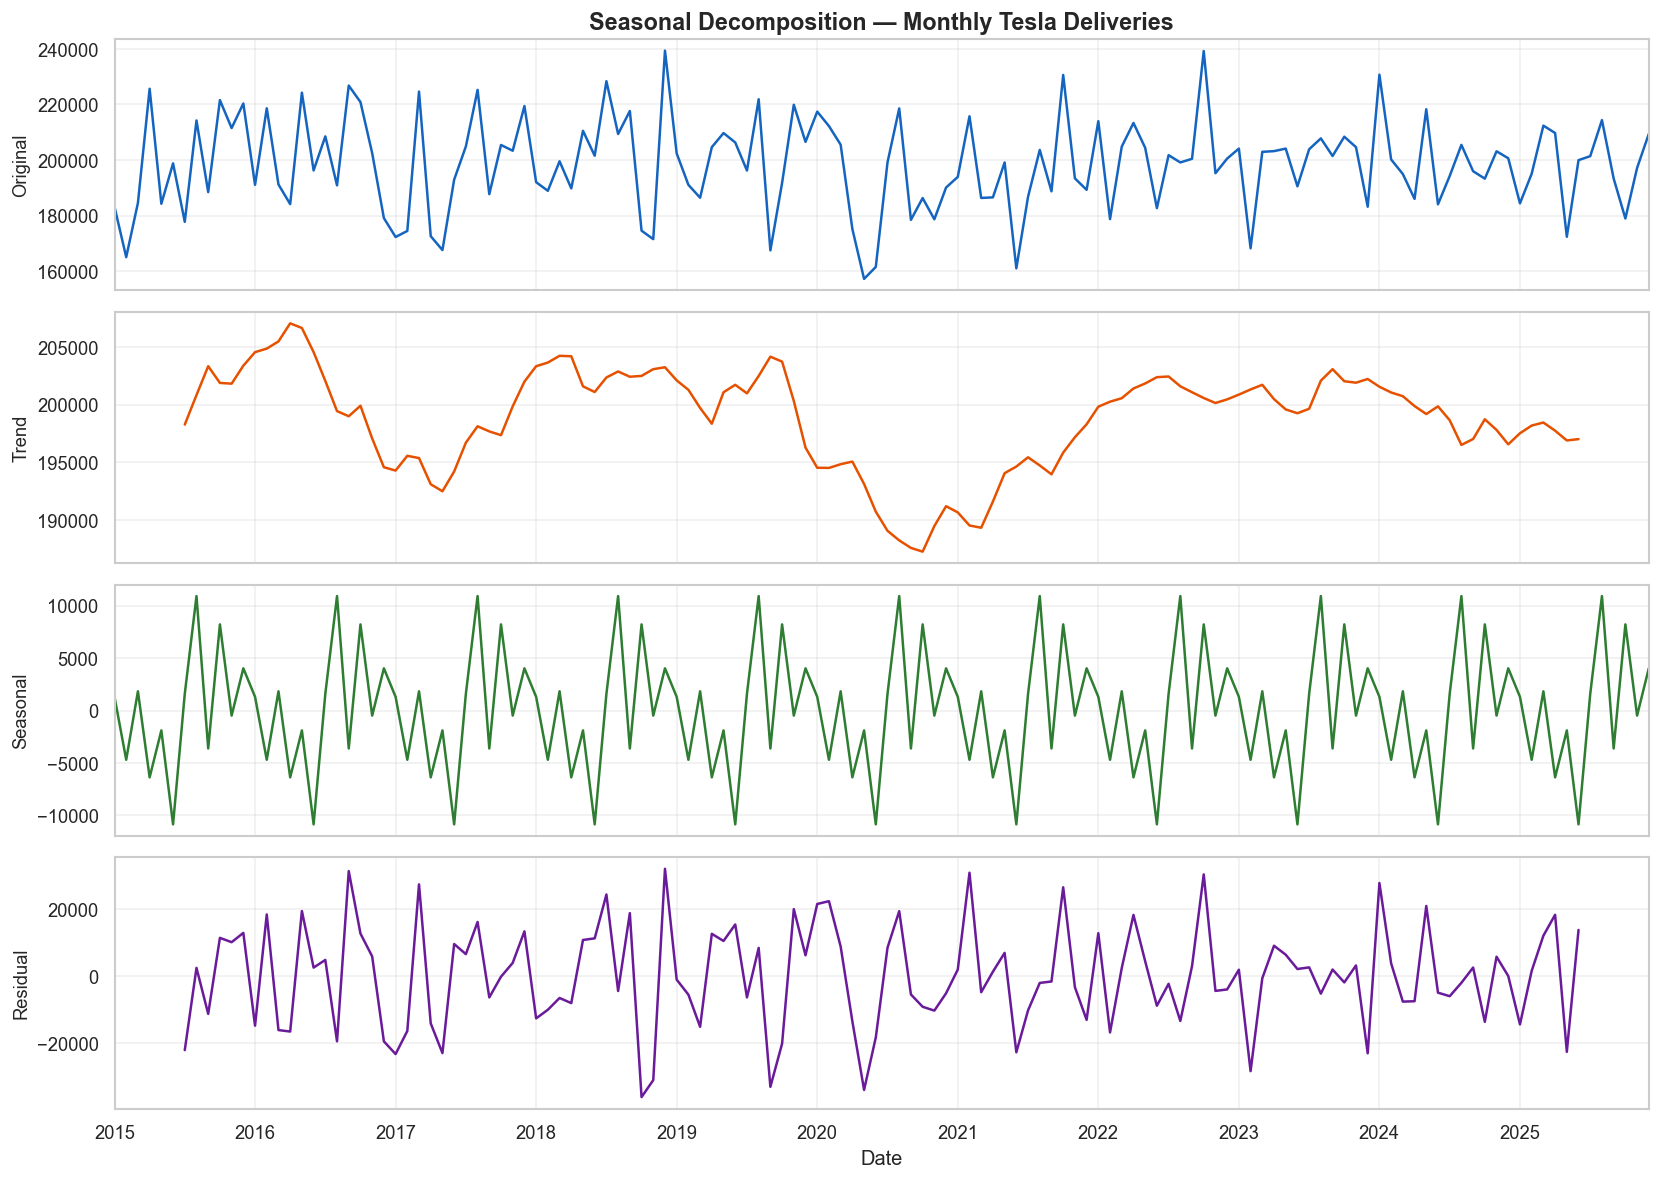

In [72]:
#  Seasonal decomposition 
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [('Original', ts), ('Trend', decomp.trend),
              ('Seasonal', decomp.seasonal), ('Residual', decomp.resid)]

colors = ['#1565c0', '#e65100', '#2e7d32', '#6a1b9a']
for ax, (label, comp), color in zip(axes, components, colors):
    comp.plot(ax=ax, color=color, linewidth=1.5)
    ax.set_ylabel(label, fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Seasonal Decomposition — Monthly Tesla Deliveries', fontweight='bold')
plt.tight_layout(); plt.show()


In [34]:
# ── 9.4  Fit SARIMA model ──
# SARIMA(p,d,q)(P,D,Q,s) — p=2, d=1, q=1, seasonal period s=12
# (params chosen based on typical monthly delivery patterns; refine with AIC if needed)

print("Fitting SARIMA(2,1,1)(1,1,1,12) ...")
sarima_model = SARIMAX(
    ts,
    order=(2, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary())


Fitting SARIMA(2,1,1)(1,1,1,12) ...


C:\Users\naren\OneDrive\Documents\Desktop\New folder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\naren\OneDrive\Documents\Desktop\New folder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1196.800
Date:                            Mon, 08 Jun 2026   AIC                           2405.601
Time:                                    00:05:25   BIC                           2421.525
Sample:                                01-01-2015   HQIC                          2412.053
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0928      0.175     -0.529      0.597      -0.436       0.251
ar.L2         -0.2284      0.159   

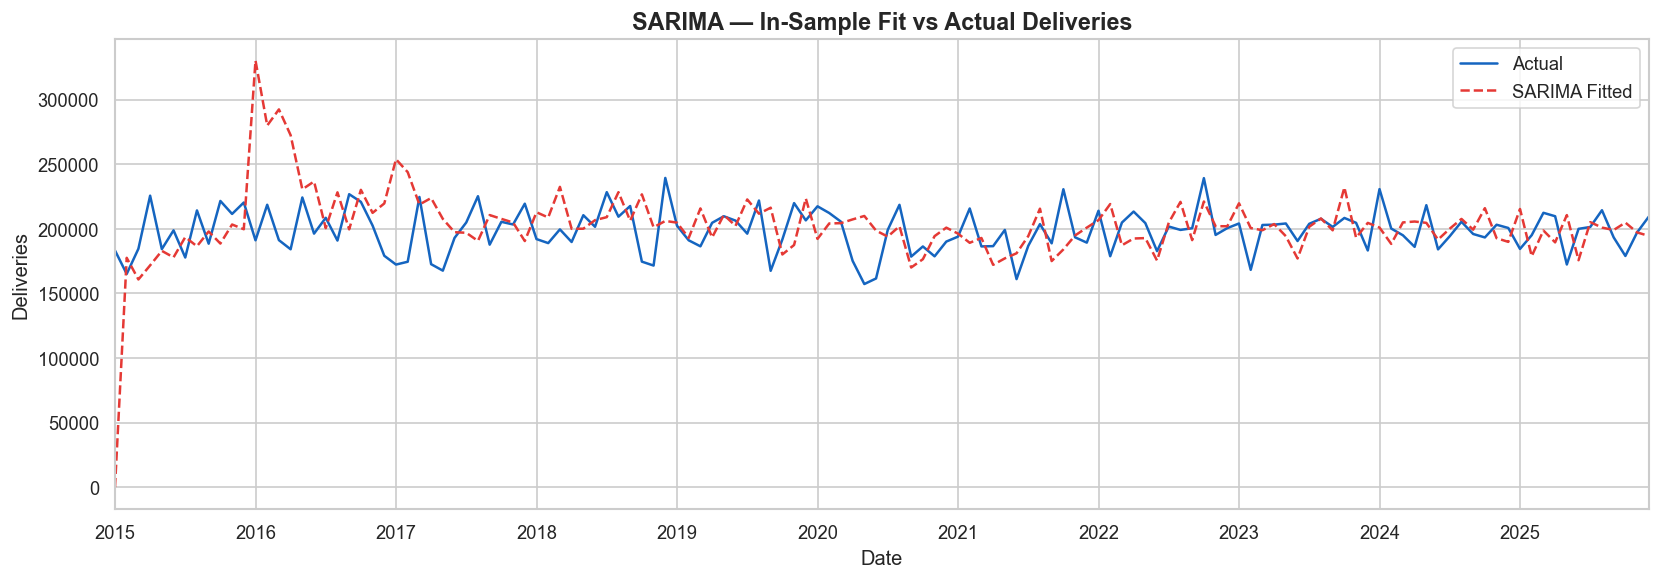


SARIMA In-Sample — R²: -2.8622 | RMSE: 33,030 | MAE: 21,634


In [73]:
# In-sample fit vs actuals 
fitted_vals = sarima_result.fittedvalues

plt.figure(figsize=(14, 5))
ts.plot(label='Actual', color='#1565c0', linewidth=1.5)
fitted_vals.plot(label='SARIMA Fitted', color='#e53935', linewidth=1.5, linestyle='--')
plt.title('SARIMA — In-Sample Fit vs Actual Deliveries', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Deliveries')
plt.legend(); plt.tight_layout(); plt.show()

# In-sample metrics 
valid = ts.index.isin(fitted_vals.index)
rmse_s = np.sqrt(mean_squared_error(ts[valid], fitted_vals[valid]))
mae_s  = mean_absolute_error(ts[valid], fitted_vals[valid])
r2_s   = r2_score(ts[valid], fitted_vals[valid])
print(f"\nSARIMA In-Sample — R²: {r2_s:.4f} | RMSE: {rmse_s:,.0f} | MAE: {mae_s:,.0f}")


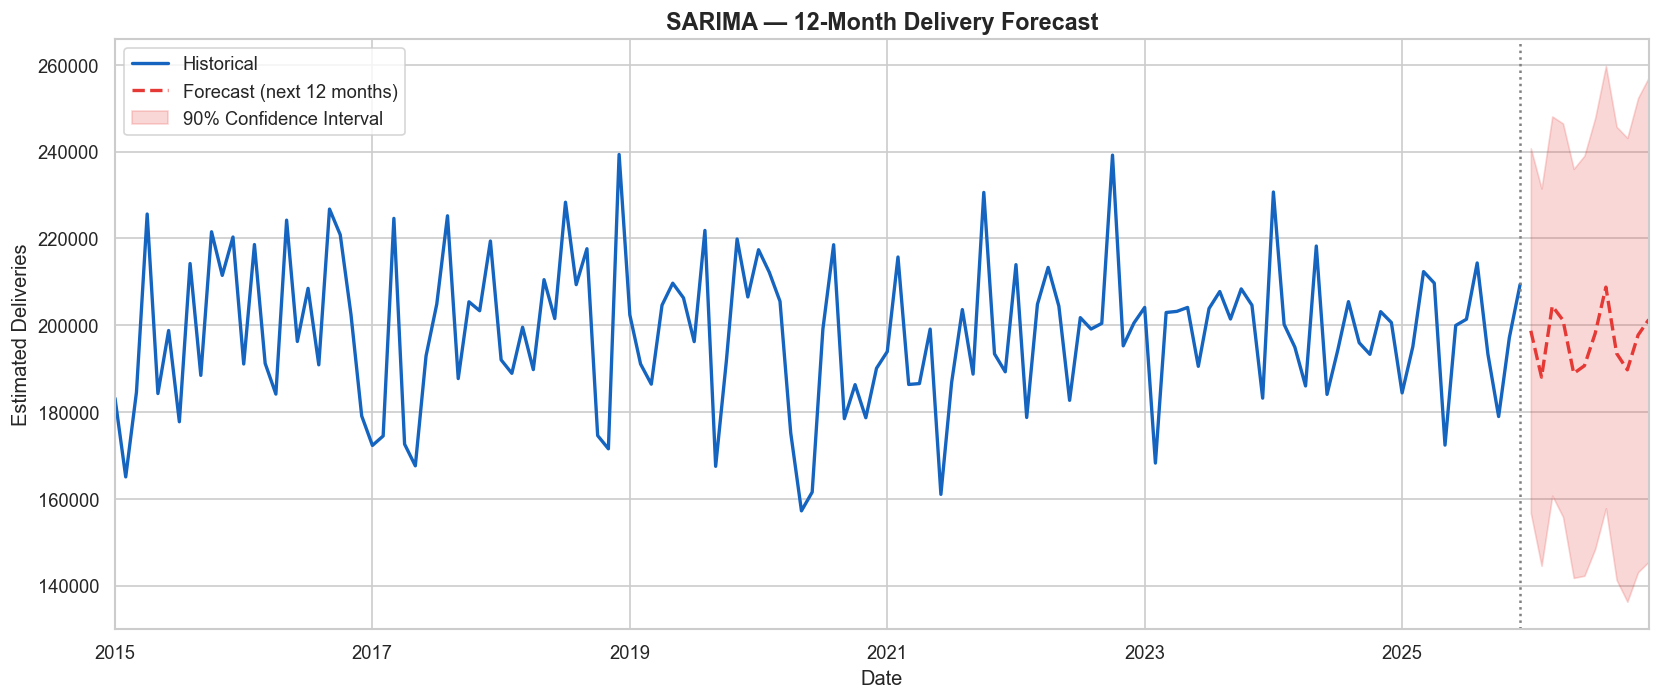


── 12-Month Forecast ──
            Forecast  Lower 90%  Upper 90%
2026-01-01    198730     156708     240752
2026-02-01    188033     144565     231501
2026-03-01    204428     160739     248117
2026-04-01    201168     155843     246494
2026-05-01    188901     141777     236026
2026-06-01    190673     142268     239079
2026-07-01    198108     148459     247758
2026-08-01    208787     157831     259743
2026-09-01    193511     141289     245734
2026-10-01    189731     136292     243170
2026-11-01    197734     143102     252366
2026-12-01    201319     145515     257122


In [36]:
# Forecast next 12 months 
N_FORECAST = 12

forecast = sarima_result.get_forecast(steps=N_FORECAST)
fc_mean   = forecast.predicted_mean
fc_ci     = forecast.conf_int(alpha=0.10)   # 90% confidence interval

# Build date index for forecast
last_date  = ts.index[-1]
fc_dates   = pd.date_range(start=last_date + pd.DateOffset(months=1),
                            periods=N_FORECAST, freq='MS')
fc_mean.index = fc_ci.index = fc_dates

# Plot 
plt.figure(figsize=(14, 6))
ts.plot(label='Historical', color='#1565c0', linewidth=2)
fc_mean.plot(label='Forecast (next 12 months)', color='#e53935', linewidth=2, linestyle='--')
plt.fill_between(fc_dates, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                 alpha=0.2, color='#e53935', label='90% Confidence Interval')
plt.axvline(ts.index[-1], color='grey', linestyle=':', linewidth=1.5)
plt.title('SARIMA — 12-Month Delivery Forecast', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Estimated Deliveries')
plt.legend(); plt.tight_layout(); plt.show()

print("\n── 12-Month Forecast ──")
fc_table = pd.DataFrame({'Forecast': fc_mean.round(0).astype(int),
                          'Lower 90%': fc_ci.iloc[:, 0].round(0).astype(int),
                          'Upper 90%': fc_ci.iloc[:, 1].round(0).astype(int)})
print(fc_table.to_string())


## Pipeline Summary & Conclusions

In [74]:
# Final comparison
print("                  END-TO-END ML PIPELINE — FINAL SUMMARY")


print("\n Dataset:")
print(f"   Records : {df.shape[0]:,}  |  Features : {df.shape[1]}")
print(f"   Period  : 2015–2025  |  Regions : {df['Region'].nunique()}  |  Models : {df['Model'].nunique()}")

print("\n Regression Target: Avg_Price_USD")
print(f"   Mean Price : ${y.mean():,.0f}  |  Std : ${y.std():,.0f}")

print("\n Best Regression Model (after tuning):")
print(f"   Model  : Tuned Random Forest")
print(f"   R²     : {r2_t:.4f}")
print(f"   RMSE   : ${rmse_t:,.2f}")
print(f"   MAE    : ${mae_t:,.2f}")
print(f"   MAPE   : {mape_t:.2f}%")

print("\n Time-Series Forecasting:")
print(f"   Model    : SARIMA(2,1,1)(1,1,1,12)")
print(f"   In-sample R²   : {r2_s:.4f}")
print(f"   In-sample RMSE : {rmse_s:,.0f}")
print(f"   Forecast horizon: 12 months (2026)")

print("\n Key Insights from EDA:")
print("   • Model Y and Model 3 dominate deliveries globally")
print("   • North America leads regional deliveries")
print("   • Deliveries peak in Q4 (month 12) each year — strong seasonality")
print("   • CO₂ savings grew ~10× from 2015 to 2025")
print("   • Production closely tracks deliveries (r ≈ 0.97)")


                  END-TO-END ML PIPELINE — FINAL SUMMARY

📌 Dataset:
   Records : 2,640  |  Features : 12
   Period  : 2015–2025  |  Regions : 4  |  Models : 5

📌 Regression Target: Avg_Price_USD
   Mean Price : $84,907  |  Std : $20,123

📌 Best Regression Model (after tuning):
   Model  : Tuned Random Forest
   R²     : 0.9923
   RMSE   : $1,701.86
   MAE    : $1,287.90
   MAPE   : 1.64%

📌 Time-Series Forecasting:
   Model    : SARIMA(2,1,1)(1,1,1,12)
   In-sample R²   : -2.8622
   In-sample RMSE : 33,030
   Forecast horizon: 12 months (2026)

📌 Key Insights from EDA:
   • Model Y and Model 3 dominate deliveries globally
   • North America leads regional deliveries
   • Deliveries peak in Q4 (month 12) each year — strong seasonality
   • CO₂ savings grew ~10× from 2015 to 2025
   • Production closely tracks deliveries (r ≈ 0.97)
